# Snake Agent with Q-Learning

This notebook takes the original Snake + Q-learning script and rebuilds it into a
proper reinforcement learning project: a correct Markovian state representation,
epsilon decay, reward shaping, persistence, metrics, hyperparameter comparison,
and a replay/visualization system for the trained agent.

Q-learning (Watkins, 1989) updates a value function `Q(s, a)` using the Bellman
equation:

```
Q(s, a) <- Q(s, a) + alpha * [ r + gamma * max_a' Q(s', a') - Q(s, a) ]
```

This update is only meaningful if the environment is (approximately) a **Markov
Decision Process** — i.e. the reward and next-state distribution depend only on
`(s, a)`, not on hidden information.

In the original script, the state was just the snake's **head coordinates**
`(x, y)` on a 5x5 grid. But the reward (`+10` for eating, `-100` for dying)
depends heavily on where the **food** is — and food position was never part of
the state. Two visits to the exact same head coordinate could have completely
different correct actions depending on where the food happens to be that
episode. This breaks the Markov assumption the whole algorithm depends on, so
the Q-table was essentially learning noise averaged over random food positions.


In [1]:
import numpy as np
import random
import pickle
import json
from collections import deque, defaultdict
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display
from tqdm import tqdm

RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

## Environment

In [2]:
UP, DOWN, LEFT, RIGHT = (0, -1), (0, 1), (-1, 0), (1, 0)
ACTIONS = [UP, DOWN, LEFT, RIGHT]
ACTION_NAMES = ["UP", "DOWN", "LEFT", "RIGHT"]

class SnakeEnv:
    """Headless Snake environment with a Gym-like step/reset API."""

    def __init__(self, grid_size=8, shaped_reward=True):
        self.grid_size = grid_size
        self.shaped_reward = shaped_reward
        self.reset()

    def reset(self):
        mid = self.grid_size // 2
        self.snake = [(mid, mid)]
        self.direction = random.choice(ACTIONS)
        self.food = self._spawn_food()
        self.steps_since_food = 0
        self.max_steps_without_food = self.grid_size * self.grid_size * 4
        return self._get_state()

    def _spawn_food(self):
        while True:
            pos = (random.randint(0, self.grid_size - 1),
                   random.randint(0, self.grid_size - 1))
            if pos not in self.snake:
                return pos

    def _is_collision(self, pos):
        x, y = pos
        if x < 0 or x >= self.grid_size or y < 0 or y >= self.grid_size:
            return True
        if pos in self.snake[:-1]:  # tail cell moves away, so exclude it
            return True
        return False

    def _get_state(self):
        head_x, head_y = self.snake[0]
        food_x, food_y = self.food
        dx = np.sign(food_x - head_x)   # -1, 0, 1
        dy = np.sign(food_y - head_y)   # -1, 0, 1

        dir_x, dir_y = self.direction
        straight = (head_x + dir_x, head_y + dir_y)
        left_dir = (dir_y, -dir_x)   # rotate direction -90deg
        right_dir = (-dir_y, dir_x)  # rotate direction +90deg
        left = (head_x + left_dir[0], head_y + left_dir[1])
        right = (head_x + right_dir[0], head_y + right_dir[1])

        danger_straight = int(self._is_collision(straight))
        danger_left = int(self._is_collision(left))
        danger_right = int(self._is_collision(right))

        direction_idx = ACTIONS.index(self.direction)

        return (int(dx), int(dy), danger_straight, danger_left, danger_right, direction_idx)

    def step(self, action):
        prev_head = self.snake[0]
        prev_dist = abs(prev_head[0] - self.food[0]) + abs(prev_head[1] - self.food[1])

        self.direction = action
        new_head = (prev_head[0] + action[0], prev_head[1] + action[1])

        died = self._is_collision(new_head)
        info = {"ate_food": False}

        if died:
            reward = -100.0
            done = True
            # keep last valid state for logging; don't mutate snake into a wall
            return self._get_state(), reward, done, info

        self.snake = [new_head] + self.snake[:-1]

        ate = new_head == self.food
        if ate:
            self.snake.append(self.snake[-1])
            self.food = self._spawn_food()
            self.steps_since_food = 0
            info["ate_food"] = True
            reward = 10.0
        else:
            self.steps_since_food += 1
            reward = -0.1
            if self.shaped_reward:
                new_dist = abs(new_head[0] - self.food[0]) + abs(new_head[1] - self.food[1])
                reward += 1.0 if new_dist < prev_dist else -1.0
                reward *= 0.1  # keep shaping small relative to the main signal

        done = self.steps_since_food > self.max_steps_without_food
        if done and not ate:
            reward = -10.0  # discourage stalling / wandering forever

        return self._get_state(), reward, done, info


## Q-Learning Agent

A tabular Q-learning agent using a `dict`-backed Q-table (state tuples as keys)
rather than a fixed `np.zeros` array — this is important because the state
space here is the *cross product* of food-direction x danger-flags x heading,
not raw grid coordinates, so a dense array would be awkward and mostly empty.

Extra "agentic engineering" features added on top of vanilla Q-learning:
- **Epsilon decay** — exploration shrinks over training instead of staying fixed.
- **Save / load** — persist a trained policy to disk (`pickle`), so training
  and deployment/inference are separate steps, like a real ML pipeline.
- **Replay buffer** — a small experience buffer with batched replay updates,
  which stabilizes learning by reusing past transitions (a lightweight nod to
  DQN-style experience replay, even though this is tabular).


In [4]:
class QLearningAgent:
    def __init__(self, actions, alpha=0.1, gamma=0.9,
                 epsilon_start=1.0, epsilon_min=0.01, epsilon_decay=0.995,
                 use_replay=True, replay_capacity=5000, replay_batch=32):
        self.actions = actions
        self.n_actions = len(actions)
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.q_table = defaultdict(lambda: np.zeros(self.n_actions))

        self.use_replay = use_replay
        self.replay_buffer = deque(maxlen=replay_capacity)
        self.replay_batch = replay_batch

    def act(self, state, greedy=False):
        if (not greedy) and random.uniform(0, 1) < self.epsilon:
            return random.randint(0, self.n_actions - 1)
        return int(np.argmax(self.q_table[state]))

    def _update(self, state, action, reward, next_state, done):
        best_next = 0.0 if done else np.max(self.q_table[next_state])
        td_target = reward + self.gamma * best_next
        td_error = td_target - self.q_table[state][action]
        self.q_table[state][action] += self.alpha * td_error

    def learn(self, state, action, reward, next_state, done):
        self._update(state, action, reward, next_state, done)
        if self.use_replay:
            self.replay_buffer.append((state, action, reward, next_state, done))
            if len(self.replay_buffer) >= self.replay_batch:
                batch = random.sample(self.replay_buffer, self.replay_batch)
                for s, a, r, ns, d in batch:
                    self._update(s, a, r, ns, d)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def save(self, path):
        with open(path, "wb") as f:
            pickle.dump({
                "q_table": dict(self.q_table),
                "epsilon": self.epsilon,
                "alpha": self.alpha,
                "gamma": self.gamma,
            }, f)

    @classmethod
    def load(cls, path, actions):
        with open(path, "rb") as f:
            data = pickle.load(f)
        agent = cls(actions, alpha=data["alpha"], gamma=data["gamma"])
        agent.q_table = defaultdict(lambda: np.zeros(len(actions)), data["q_table"])
        agent.epsilon = data["epsilon"]
        return agent

## Training Loop

Fully **headless** — no per-step rendering, so this can run thousands of
episodes quickly. Metrics (reward, steps survived, food eaten, epsilon) are
logged every episode for later analysis.


In [5]:
def train(agent, env, num_episodes=2000, log_every=100, verbose=True):
    history = {"reward": [], "steps": [], "food": [], "epsilon": []}

    iterator = tqdm(range(1, num_episodes + 1), desc="Training") if verbose else range(1, num_episodes + 1)
    for episode in iterator:
        state = env.reset()
        done = False
        total_reward = 0.0
        steps = 0
        food_eaten = 0

        while not done:
            action_idx = agent.act(state)
            action = agent.actions[action_idx]
            next_state, reward, done, info = env.step(action)

            agent.learn(state, action_idx, reward, next_state, done)

            state = next_state
            total_reward += reward
            steps += 1
            if info.get("ate_food"):
                food_eaten += 1

        agent.decay_epsilon()

        history["reward"].append(total_reward)
        history["steps"].append(steps)
        history["food"].append(food_eaten)
        history["epsilon"].append(agent.epsilon)

        if verbose and episode % log_every == 0:
            recent = history["reward"][-log_every:]
            print(f"Episode {episode:5d} | avg reward (last {log_every}): {np.mean(recent):7.2f} "
                  f"| avg food: {np.mean(history['food'][-log_every:]):.2f} | epsilon: {agent.epsilon:.3f}")

    return history

In [6]:
env = SnakeEnv(grid_size=8, shaped_reward=True)
agent = QLearningAgent(ACTIONS, alpha=0.1, gamma=0.9,
                        epsilon_start=1.0, epsilon_min=0.02, epsilon_decay=0.997,
                        use_replay=True)

history = train(agent, env, num_episodes=3000, log_every=200)

Training:   8%|▊         | 238/3000 [00:01<00:14, 195.77it/s]

Episode   200 | avg reward (last 200):  -91.97 | avg food: 0.81 | epsilon: 0.548


Training:  14%|█▍        | 433/3000 [00:02<00:10, 242.05it/s]

Episode   400 | avg reward (last 200):  -81.11 | avg food: 1.83 | epsilon: 0.301


Training:  21%|██        | 635/3000 [00:03<00:13, 171.11it/s]

...

Episode  2600 | avg reward (last 200):   17.70 | avg food: 11.34 | epsilon: 0.020


Training:  94%|█████████▎| 2809/3000 [00:43<00:03, 55.08it/s]

Episode  2800 | avg reward (last 200):   18.68 | avg food: 11.44 | epsilon: 0.020


Training: 100%|██████████| 3000/3000 [00:46<00:00, 64.38it/s]

Episode  3000 | avg reward (last 200):   15.60 | avg food: 11.14 | epsilon: 0.020


## Training Metrics Dashboard

Reward alone is noisy episode-to-episode, so we plot both the raw reward and
a moving average, alongside food-eaten-per-episode and the epsilon decay
curve — the standard set of diagnostics to check an RL agent is actually
improving rather than just stalling.


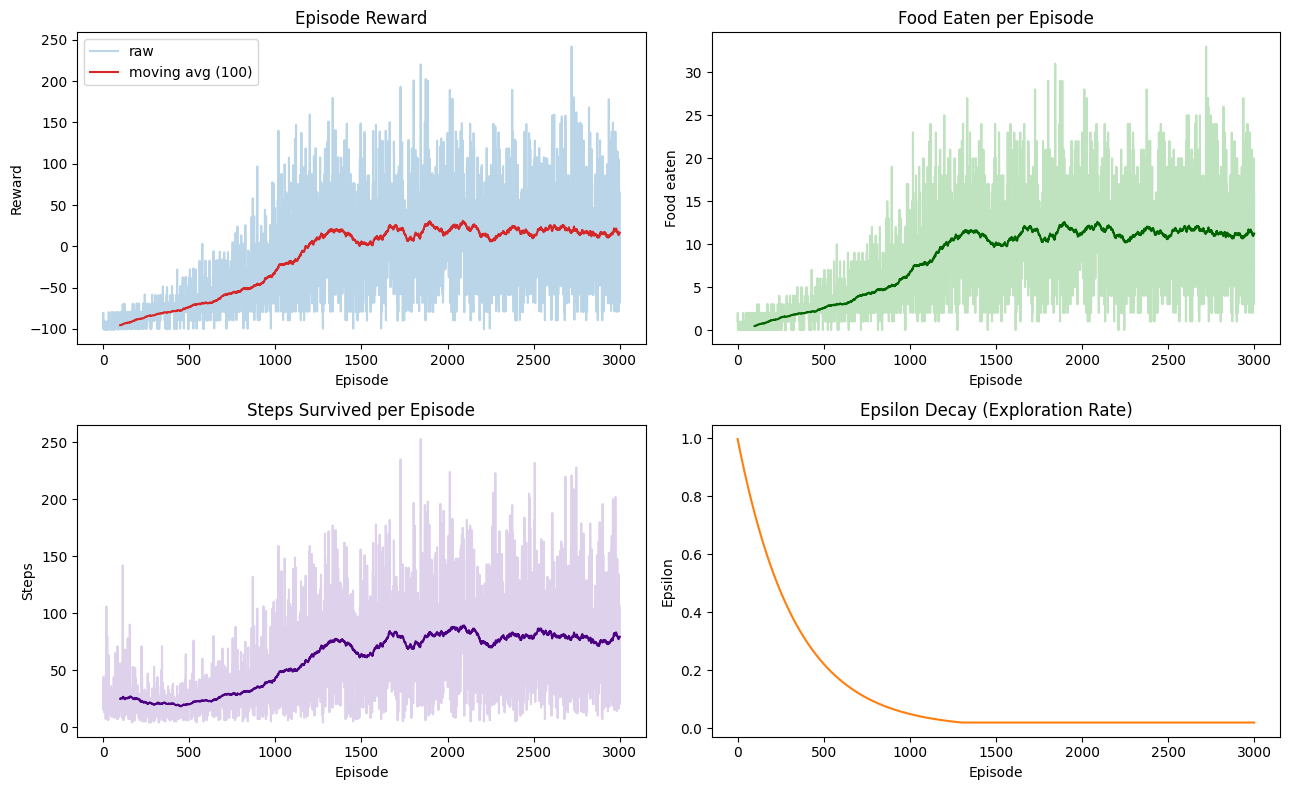

In [7]:
def moving_average(x, window=100):
    x = np.array(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

ma_reward = moving_average(history["reward"])
axes[0, 0].plot(history["reward"], alpha=0.3, label="raw")
axes[0, 0].plot(range(len(history["reward"]) - len(ma_reward), len(history["reward"])), ma_reward, color="tab:red", label="moving avg (100)")
axes[0, 0].set_title("Episode Reward")
axes[0, 0].set_xlabel("Episode"); axes[0, 0].set_ylabel("Reward"); axes[0, 0].legend()

axes[0, 1].plot(history["food"], alpha=0.3, color="tab:green")
ma_food = moving_average(history["food"])
axes[0, 1].plot(range(len(history["food"]) - len(ma_food), len(history["food"])), ma_food, color="darkgreen")
axes[0, 1].set_title("Food Eaten per Episode")
axes[0, 1].set_xlabel("Episode"); axes[0, 1].set_ylabel("Food eaten")

axes[1, 0].plot(history["steps"], alpha=0.3, color="tab:purple")
ma_steps = moving_average(history["steps"])
axes[1, 0].plot(range(len(history["steps"]) - len(ma_steps), len(history["steps"])), ma_steps, color="indigo")
axes[1, 0].set_title("Steps Survived per Episode")
axes[1, 0].set_xlabel("Episode"); axes[1, 0].set_ylabel("Steps")

axes[1, 1].plot(history["epsilon"], color="tab:orange")
axes[1, 1].set_title("Epsilon Decay (Exploration Rate)")
axes[1, 1].set_xlabel("Episode"); axes[1, 1].set_ylabel("Epsilon")

plt.tight_layout()
plt.show()

## Save the Trained Agent

Separating *training* from *inference* like this means you can train once and
reuse the policy later without retraining — closer to how a real deployed
agent would work.


In [8]:
agent.save("snake_q_agent.pkl")
print("Saved agent to snake_q_agent.pkl")
print(f"Q-table has {len(agent.q_table)} learned states.")

Saved agent to snake_q_agent.pkl
Q-table has 256 learned states.


## Watch the Trained Agent Play

Runs one greedy (no exploration) episode and renders it as a matplotlib
animation inline in the notebook — no pygame window needed.


In [9]:
def run_episode(agent, env, greedy=True, max_steps=500):
    state = env.reset()
    frames = [[pos for pos in env.snake]]
    food_frames = [env.food]
    done = False
    steps = 0
    while not done and steps < max_steps:
        action_idx = agent.act(state, greedy=greedy)
        action = agent.actions[action_idx]
        state, reward, done, info = env.step(action)
        frames.append([pos for pos in env.snake])
        food_frames.append(env.food)
        steps += 1
    return frames, food_frames

def animate_episode(frames, food_frames, grid_size):
    fig, ax = plt.subplots(figsize=(5, 5))

    def draw(i):
        ax.clear()
        ax.set_xlim(0, grid_size); ax.set_ylim(0, grid_size)
        ax.set_xticks(range(grid_size + 1)); ax.set_yticks(range(grid_size + 1))
        ax.grid(True)
        ax.set_aspect("equal")
        ax.invert_yaxis()

        fx, fy = food_frames[i]
        ax.add_patch(plt.Rectangle((fx, fy), 1, 1, color="red"))

        for (x, y) in frames[i]:
            ax.add_patch(plt.Rectangle((x, y), 1, 1, color="green"))

        ax.set_title(f"Step {i}")

    anim = animation.FuncAnimation(fig, draw, frames=len(frames), interval=200, repeat=False)
    plt.close(fig)
    return anim

frames, food_frames = run_episode(agent, env, greedy=True)
anim = animate_episode(frames, food_frames, env.grid_size)
HTML(anim.to_jshtml())

## Hyperparameter Sweep

Instead of guessing `alpha`, `gamma`, and `epsilon_decay` once, compare a
handful of configurations side by side on the same metric (average reward
over the last 200 episodes) — a small but genuinely useful "agentic
engineering" habit: never trust a single training run's hyperparameters
without a comparison baseline.


baseline        | final avg reward (last 200 eps): 12.28
high_lr         | final avg reward (last 200 eps): 17.11
low_gamma       | final avg reward (last 200 eps): 19.38
fast_decay      | final avg reward (last 200 eps): 15.42


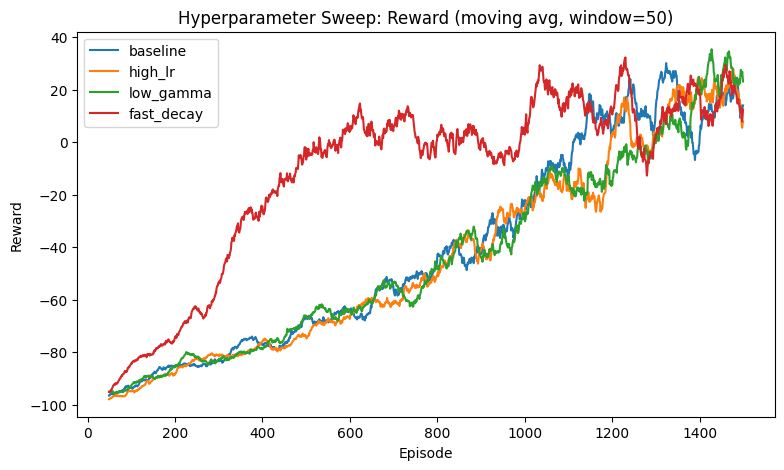

In [10]:
def run_sweep(configs, num_episodes=1500):
    results = {}
    for name, cfg in configs.items():
        env_s = SnakeEnv(grid_size=8, shaped_reward=True)
        agent_s = QLearningAgent(ACTIONS, **cfg)
        hist = train(agent_s, env_s, num_episodes=num_episodes, verbose=False)
        results[name] = hist
        print(f"{name:15s} | final avg reward (last 200 eps): {np.mean(hist['reward'][-200:]):.2f}")
    return results

sweep_configs = {
    "baseline":        dict(alpha=0.1,  gamma=0.9,  epsilon_start=1.0, epsilon_decay=0.997, epsilon_min=0.02),
    "high_lr":         dict(alpha=0.3,  gamma=0.9,  epsilon_start=1.0, epsilon_decay=0.997, epsilon_min=0.02),
    "low_gamma":       dict(alpha=0.1,  gamma=0.7,  epsilon_start=1.0, epsilon_decay=0.997, epsilon_min=0.02),
    "fast_decay":      dict(alpha=0.1,  gamma=0.9,  epsilon_start=1.0, epsilon_decay=0.99,  epsilon_min=0.02),
}

sweep_results = run_sweep(sweep_configs, num_episodes=1500)

plt.figure(figsize=(9, 5))
for name, hist in sweep_results.items():
    ma = moving_average(hist["reward"], window=50)
    plt.plot(range(49, len(hist["reward"])), ma, label=name)
plt.title("Hyperparameter Sweep: Reward (moving avg, window=50)")
plt.xlabel("Episode"); plt.ylabel("Reward"); plt.legend()
plt.show()